In [2]:
import numpy as np
from utils import annotated_heatmap
from environments import CorridorEnvTerminalReward

We can now instantiate the environment object and some parameters such as the discount factor gamma and the policy

In [8]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)

pi = [np.ones(n_actions)/n_actions]*n_states # Set the policy to a uniform distribution

In [9]:
def rollout_episode(env, pi):
    done = False
    s = np.random.randint(0,env.nS)
    trajectory = []    
    while not done:
        a = np.random.choice(possible_actions, p=pi[s])
        [p, s_, r, done] = env.step(s, a)[0]
        transition = [s, int(a), r]
        trajectory.append(transition)
        s = s_
    return trajectory

In [10]:
def monte_carlo_prediction(gamma: float = 1.0, num_episodes: int = 10):
    # Create unique dictionaries for every state and action using list comprehension because dict is mutable
    returns = [[{"avg_return": 0.0, "freq": 0} for _ in range(n_actions)] for _ in range(n_states)]

    # Similarly for the q-table to be safe using list comprehension because list is mutable
    q = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]

    v = [0.0]*n_states # this can be defined using "*" instead of list comprehension because int is immutable

    for e in range(num_episodes):
        trajectory = rollout_episode(env, pi)
        G = 0
        for s, a, r in reversed(trajectory):
            G = G*gamma + r
            new_freq = returns[s][a]["freq"] + 1
            returns[s][a]["avg_return"] = (returns[s][a]["avg_return"]*returns[s][a]["freq"] + G)/new_freq
            returns[s][a]["freq"] = new_freq
            q[s][a] = returns[s][a]["avg_return"]
            v[s] = max(q[s])
    return v

In [11]:
v = monte_carlo_prediction(gamma=0.95, num_episodes=100)

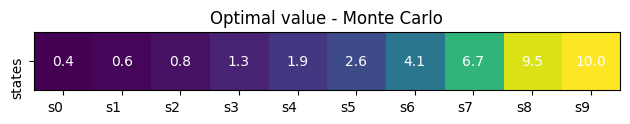

In [12]:
annotated_heatmap([v], "Optimal value - Monte Carlo")